# Complexity vs. robustness tradeoff

The re-default-aware formula has two more free parameters ($P_{rd}$ and $RR_{brd}$) than the basic formula, estimated from however many re-defaults happen to show up in a given reference dataset. At small sample sizes, or portfolios with few observed re-defaults, that extra flexibility can add more estimation variance than it saves in structural bias. This notebook sweeps portfolio size and asks: at what point, if any, does the added variance from the more complex formula's extra parameters outweigh its lower bias?

In [1]:
import numpy as np

from lgd_sim.dgp import DGPParams
from lgd_sim.experiment import run_complexity_sweep
from lgd_sim.metrics import summarize, summarize_rmse
from lgd_sim.plotting import plot_bias_variance_decomposition, plot_rmse_sweep

SEED = 42
N_EXPOSURES_VALUES = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
N_REPLICATIONS = 1000
BASE_PARAMS = DGPParams(pc=0.2, prd=0.1)
RESULTS_DIR = "../results"

## Portfolio-size sweep, at $PC = 0.2$, $P_{rd} = 0.1$

At this base case, about 2% of exposures ($PC \times P_{rd}$) end up observed as re-defaults, so the observed re-default count tracks portfolio size in fixed proportion throughout this sweep; the x-axis below is labeled in exposures, not re-defaults, but the two move together.

In [2]:
complexity_results = run_complexity_sweep(
    n_exposures_values=N_EXPOSURES_VALUES,
    base_params=BASE_PARAMS,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)
complexity_summary = summarize_rmse(complexity_results, sweep_param="n_exposures")
complexity_summary.to_csv(f"{RESULTS_DIR}/complexity_rmse_summary.csv", index=False)
complexity_summary

,n_exposures,lgd_basic_error_rmse,lgd_lgc_error_rmse,lgd_prd_error_rmse,lgd_new_error_rmse,n_redefault_mean,n_replications
0,100,0.024159,0.025615,0.027574,0.021968,1.995,1000
1,200,0.017293,0.017425,0.019774,0.014860,3.804,1000
2,500,0.012170,0.011288,0.015468,0.009015,9.834,1000
3,1000,0.010246,0.008901,0.014273,0.006567,20.114,1000
4,2000,0.009222,0.007027,0.012939,0.004713,39.604,1000
5,5000,0.008482,0.005751,0.012430,0.003000,100.048,1000
6,10000,0.008237,0.005072,0.012054,0.002043,199.450,1000
7,20000,0.008060,0.004890,0.012051,0.001507,399.917,1000
8,50000,0.007997,0.004649,0.011926,0.000937,998.821,1000


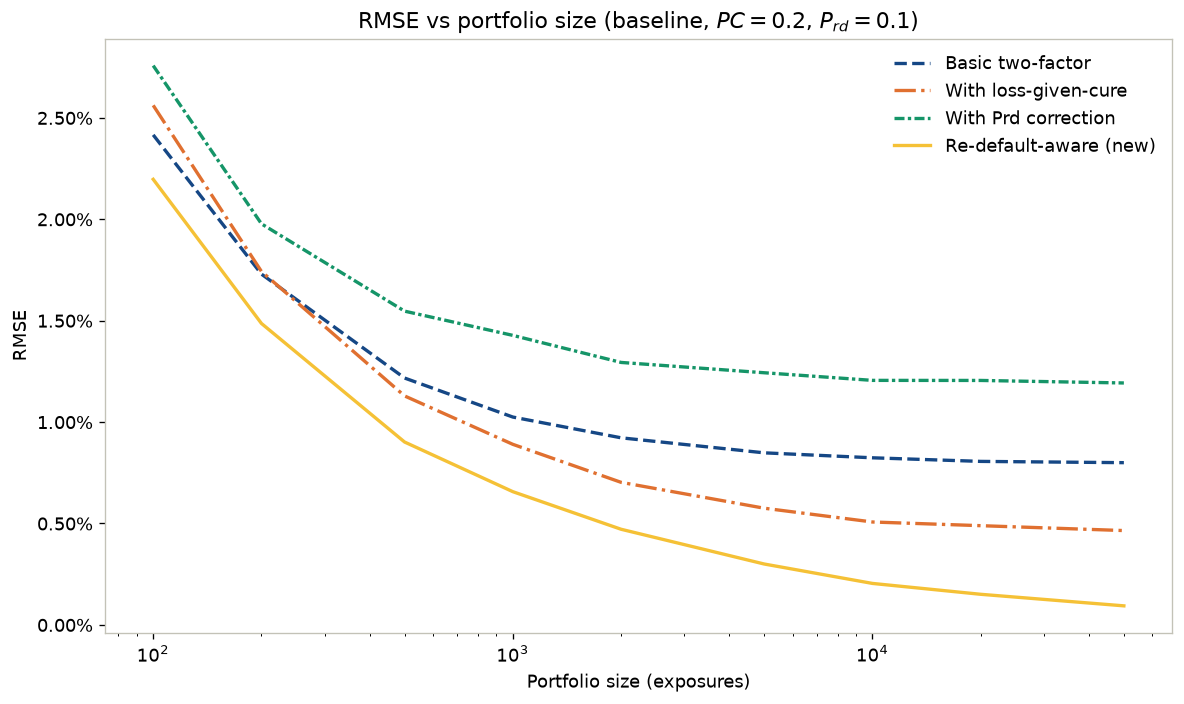

In [3]:
fig = plot_rmse_sweep(
    complexity_summary,
    x_column="n_exposures",
    x_label="Portfolio size (exposures)",
    title="RMSE vs portfolio size (baseline, $PC=0.2$, $P_{rd}=0.1$)",
)
fig.savefig(f"{RESULTS_DIR}/complexity_rmse_vs_n_exposures.png", bbox_inches="tight")

### Bias/variance decomposition

RMSE conflates two different things: whether a formula systematically over- or under-estimates $LGD_{true}$ (bias), and how much its estimate bounces around given the data actually drawn (standard deviation). Splitting them out shows whether the re-default-aware formula's lower RMSE comes at the cost of higher variance, or not.

In [4]:
bias_sd_summary = summarize(complexity_results, sweep_param="n_exposures")
bias_sd_columns = ["n_exposures"] + [
    f"{formula}_error_{stat}"
    for formula in ["lgd_basic", "lgd_lgc", "lgd_prd", "lgd_new"]
    for stat in ["mean", "sd"]
]
bias_sd_summary = bias_sd_summary[bias_sd_columns]
bias_sd_summary.to_csv(f"{RESULTS_DIR}/complexity_bias_sd_summary.csv", index=False)
bias_sd_summary

,n_exposures,lgd_basic_error_mean,lgd_basic_error_sd,lgd_lgc_error_mean,lgd_lgc_error_sd,lgd_prd_error_mean,lgd_prd_error_sd,lgd_new_error_mean,lgd_new_error_sd
0,100,-0.007059,0.023116,0.005368,0.025059,0.012680,0.024498,0.000560,0.021972
1,200,-0.007825,0.015429,0.003945,0.016981,0.011013,0.016431,-0.000329,0.014864
2,500,-0.007609,0.009503,0.004800,0.010221,0.011892,0.009896,0.000217,0.009017
3,1000,-0.007636,0.006835,0.004896,0.007437,0.012317,0.007215,0.000292,0.006563
4,2000,-0.007792,0.004935,0.004576,0.005335,0.011852,0.005194,0.000026,0.004716
5,5000,-0.007896,0.003097,0.004614,0.003435,0.011954,0.003410,0.000002,0.003001
6,10000,-0.007947,0.002166,0.004514,0.002314,0.011838,0.002274,-0.000040,0.002043
7,20000,-0.007904,0.001578,0.004584,0.001703,0.011934,0.001678,-0.000008,0.001507
8,50000,-0.007937,0.000978,0.004526,0.001062,0.011881,0.001044,-0.000041,0.000937


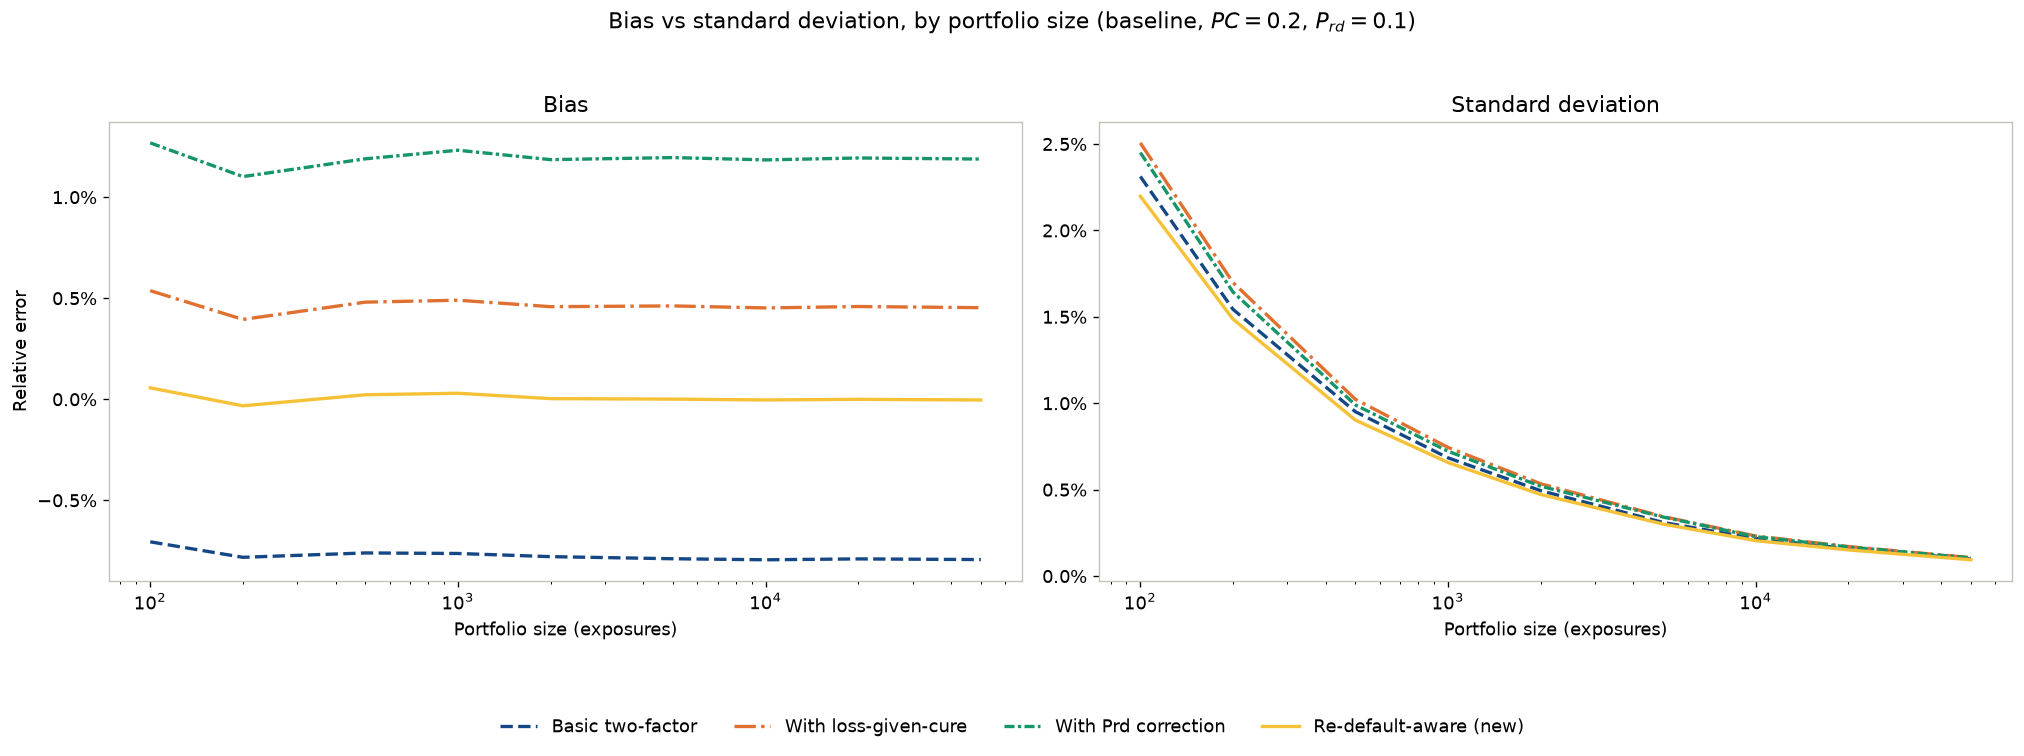

In [5]:
fig = plot_bias_variance_decomposition(
    bias_sd_summary,
    sweep_param="n_exposures",
    x_label="Portfolio size (exposures)",
    title="Bias vs standard deviation, by portfolio size (baseline, $PC=0.2$, $P_{rd}=0.1$)",
)
fig.savefig(f"{RESULTS_DIR}/complexity_bias_variance_decomposition.png", bbox_inches="tight")

In [ ]:
smallest = complexity_results[complexity_results["n_exposures"] == N_EXPOSURES_VALUES[0]]
zero_redefault = smallest[smallest["n_redefault"] == 0]
formula_columns = ["lgd_basic", "lgd_lgc", "lgd_prd", "lgd_new"]
max_spread = (
    zero_redefault[formula_columns].max(axis=1) - zero_redefault[formula_columns].min(axis=1)
).max()

print(
    f"{len(zero_redefault)} of {N_REPLICATIONS} replications at n_exposures={N_EXPOSURES_VALUES[0]} "
    f"observed zero re-defaults; max spread across formulas in those replications: {max_spread:.2e}"
)

130 of 1000 replications at n_exposures=100 observed zero re-defaults; max spread across formulas in those replications: 0.00e+00


## Summary

No crossover shows up anywhere in this sweep, and the reason goes further than "the bias advantage wins": decomposing RMSE into bias and standard deviation shows the re-default-aware formula isn't trading variance for its lower bias at all.

Each formula's bias settles into a flat floor as portfolio size grows, structural rather than sample-size-driven: about -0.76% to -0.79% for the basic formula, +0.45% to +0.49% for loss-given-cure, +1.18% to +1.23% for the Prd-correction, and essentially 0% for the re-default-aware formula, from 500 exposures upward. At the two smallest sizes tested (100 and 200), the bias estimates scatter a bit wider than that band, since estimating a mean from only 1,000 replications is less precise when each replication's own error has this much spread, not because the underlying bias is actually shifting with sample size. Standard deviation, unlike bias, does shrink steadily with portfolio size for all four formulas, but the ranking never changes: the re-default-aware formula has the smallest SD of all four at every single portfolio size tested, from 100 exposures up to 50,000, not just smaller than the basic formula's. Its extra parameters, $P_{rd}$ and $RR_{brd}$, never add enough estimation noise to overtake even the simplest formula's variance, let alone offset its own near-zero bias.

The reason traces back to the formula itself: both correction terms are multiplied by $P_{rd}$, so when a replication happens to observe zero re-defaults, $\hat{P}_{rd} = 0$ and the formula collapses exactly to the basic two-factor estimate rather than picking up extra noise from an unstable $\hat{P}_{rd}$ or $\hat{RR}_{brd}$. At $n=100$, 130 of 1,000 replications drew zero re-defaults; in every one of those, all four formulas' predicted LGD values matched exactly, confirming the collapse holds precisely, not just on average.

This doesn't rule out a bias-variance tradeoff existing under a misspecified DGP, where the re-default-aware formula's lower bias, and its apparent variance advantage, are no longer guaranteed. That's what the [misspecification experiment](04_misspecification_stress_test.ipynb) is for.